In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
# English Premier League 2018-2019 season match results
# Dataset: E0_2018-2019.csv
from pandas import read_csv
df = read_csv("E0_2018-2019.csv")
df.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,PSCH,PSCD,PSCA
0,E0,10/8/2018,Man United,Leicester,2,1,H,1,0,H,...,1.79,17,-0.75,1.75,1.70,2.29,2.21,1.55,4.07,7.69
1,E0,11/8/2018,Bournemouth,Cardiff,2,0,H,1,0,H,...,1.83,20,-0.75,2.20,2.13,1.80,1.75,1.88,3.61,4.70
2,E0,11/8/2018,Fulham,Crystal Palace,0,2,A,0,1,A,...,1.87,22,-0.25,2.18,2.11,1.81,1.77,2.62,3.38,2.90
3,E0,11/8/2018,Huddersfield,Chelsea,0,3,A,0,2,A,...,1.84,23,1.00,1.84,1.80,2.13,2.06,7.24,3.95,1.58
4,E0,11/8/2018,Newcastle,Tottenham,1,2,A,1,2,A,...,1.81,20,0.25,2.20,2.12,1.80,1.76,4.74,3.53,1.89


In [4]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA']
Categorical Features: ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTR', 'HTR', 'Referee']


/tmp/ipykernel_520/1869842994.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [5]:
# Select the core match-statistic columns for correlation analysis
# (the full betting-odds columns are excluded here to keep the heatmap readable)
numerical_cols = ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST',
                   'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
corr_matrix = df[numerical_cols].corr()

In [6]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
          FTHG      FTAG      HTHG      HTAG        HS        AS       HST  \
FTHG  1.000000 -0.178097  0.694242 -0.078393  0.332258 -0.181487  0.586005   
FTAG -0.178097  1.000000 -0.109562  0.687816 -0.158431  0.290718 -0.140937   
HTHG  0.694242 -0.109562  1.000000 -0.016028  0.154100 -0.054232  0.356043   
HTAG -0.078393  0.687816 -0.016028  1.000000 -0.059493  0.169608 -0.060141   
HS    0.332258 -0.158431  0.154100 -0.059493  1.000000 -0.491028  0.694055   
AS   -0.181487  0.290718 -0.054232  0.169608 -0.491028  1.000000 -0.301041   
HST   0.586005 -0.140937  0.356043 -0.060141  0.694055 -0.301041  1.000000   
AST  -0.195043  0.545118 -0.118996  0.378806 -0.312785  0.638406 -0.179892   
HF   -0.062223  0.076273 -0.052470  0.082233 -0.170446  0.140739 -0.086817   
AF   -0.060194 -0.036571  0.040455 -0.000537  0.027964 -0.076502 -0.047630   
HC    0.086339 -0.135966 -0.075253 -0.083059  0.587135 -0.433024  0.381402   
AC   -0.134962  0.035167 -0.021978 -

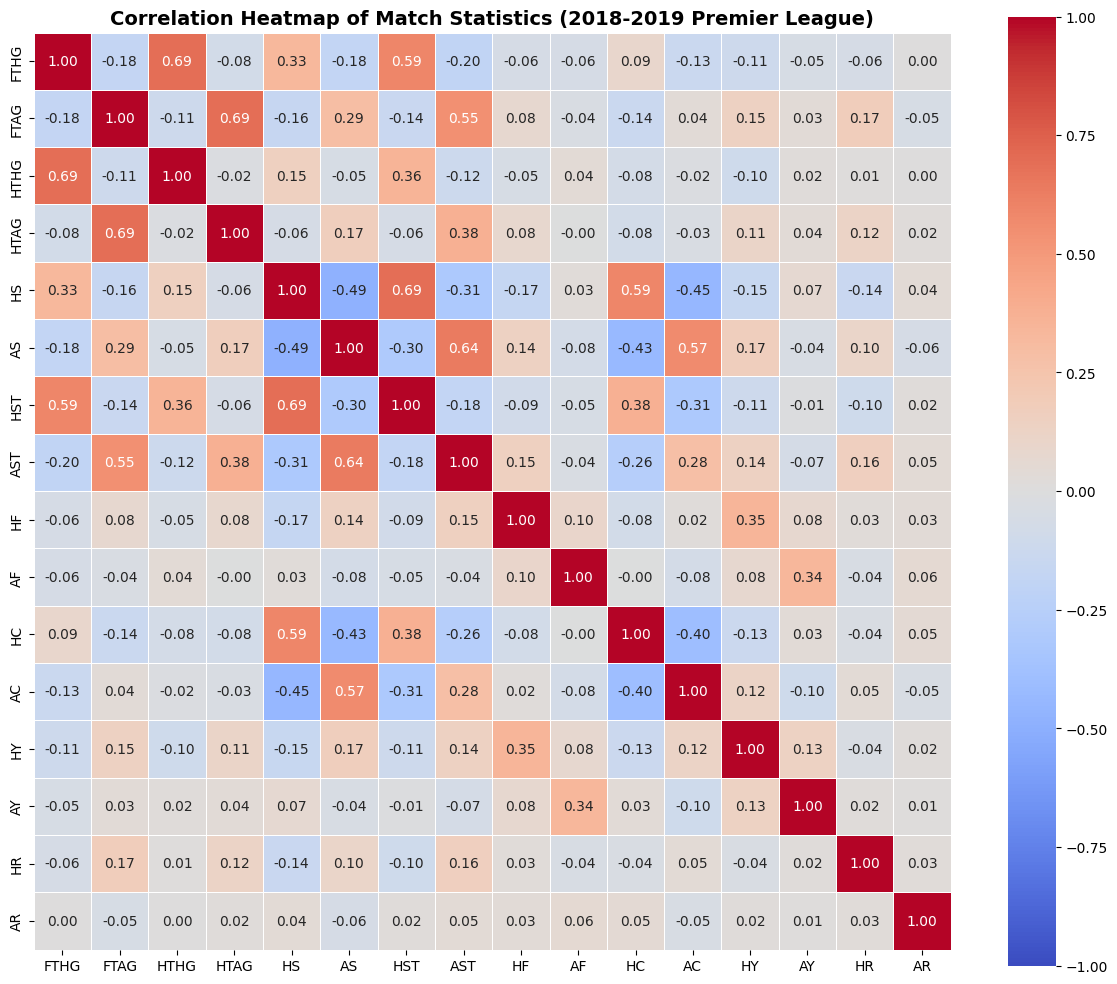

In [7]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Match Statistics (2018-2019 Premier League)", fontsize=14, fontweight="bold")
plt.tight_layout()

In [8]:
# Export Heatmap
import os
output_dir = "."
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: ./correlation_heatmap.png


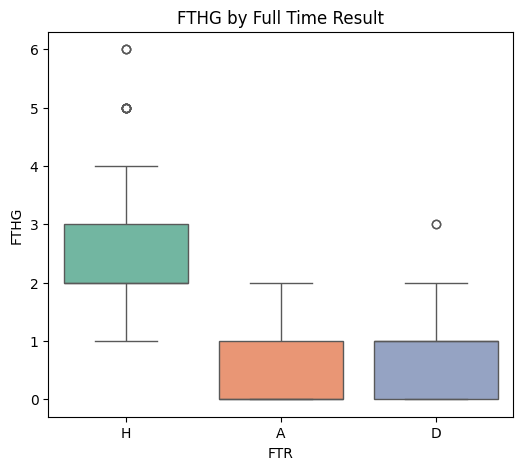

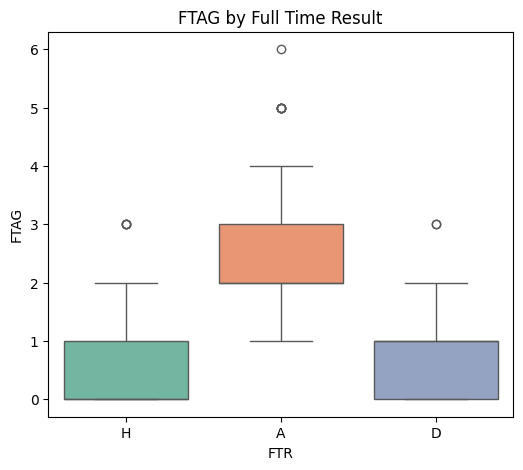

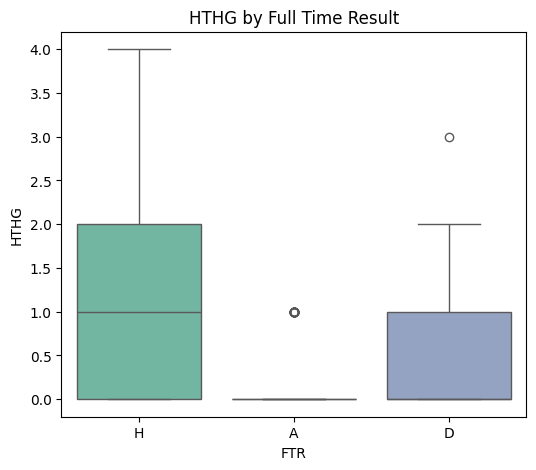

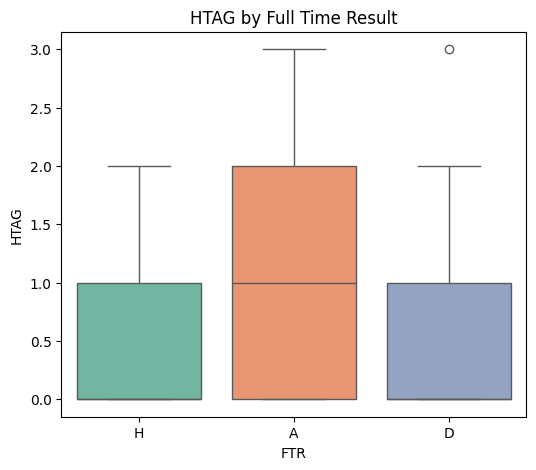

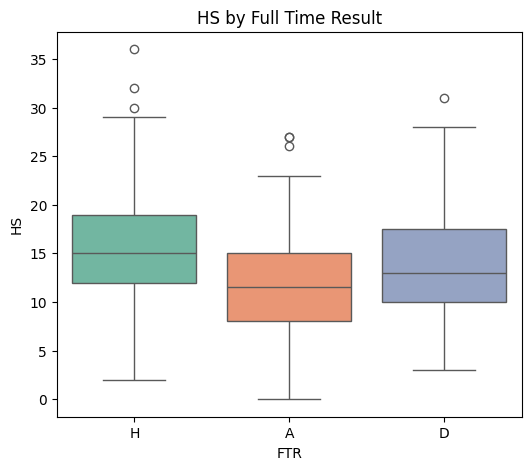

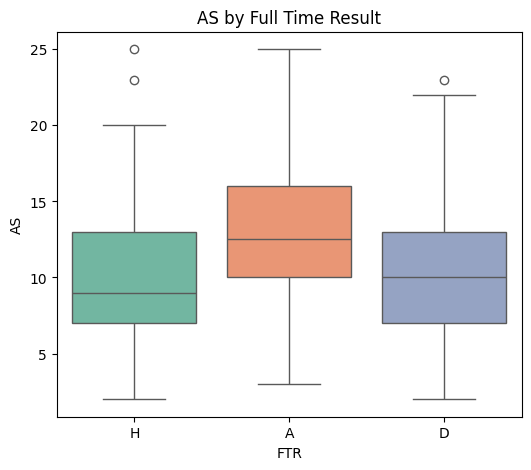

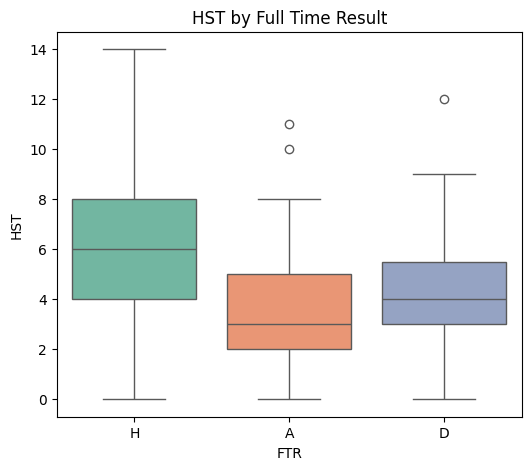

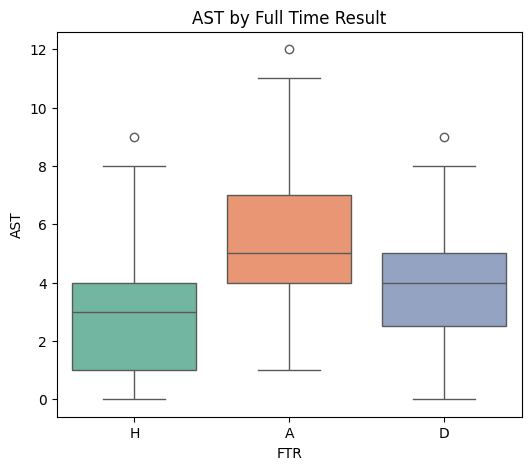

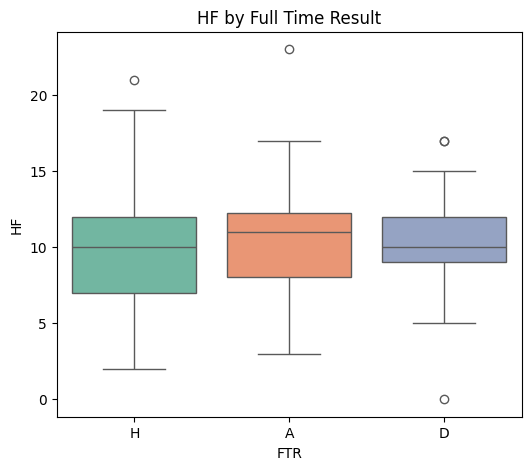

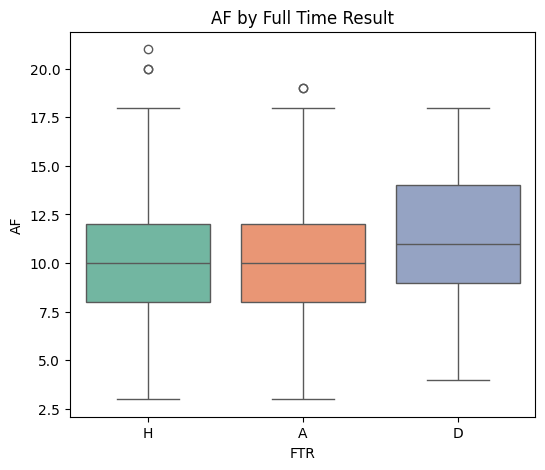

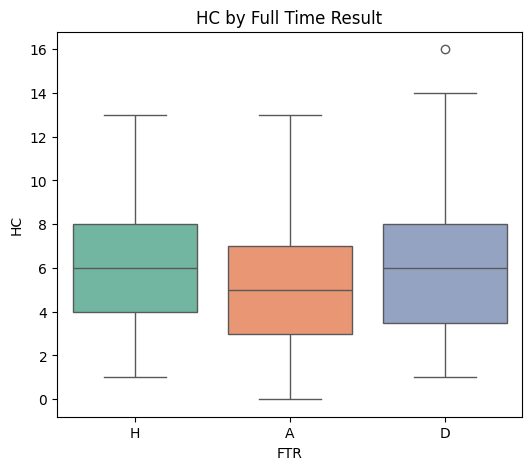

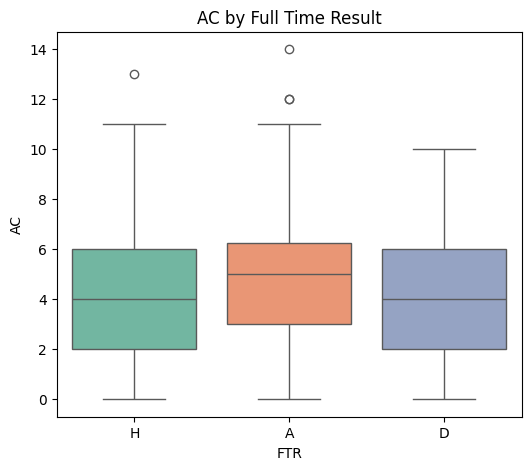

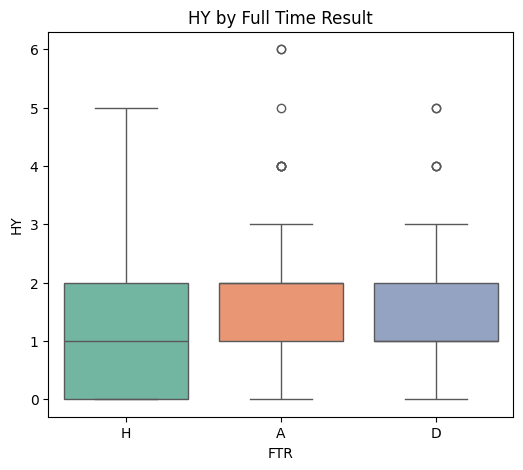

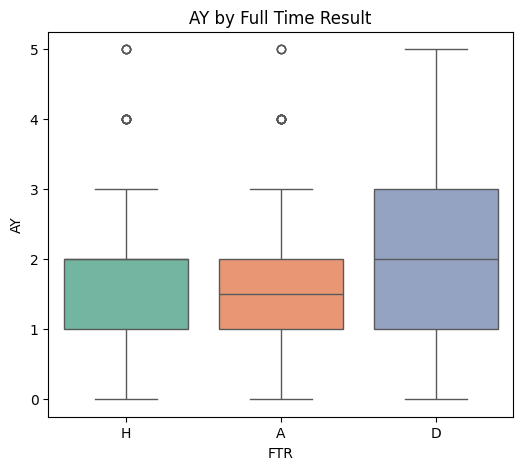

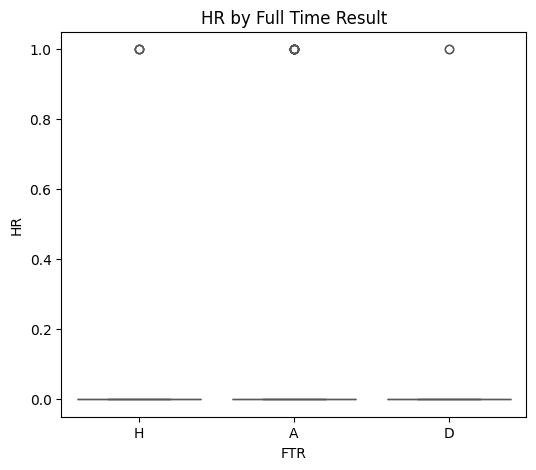

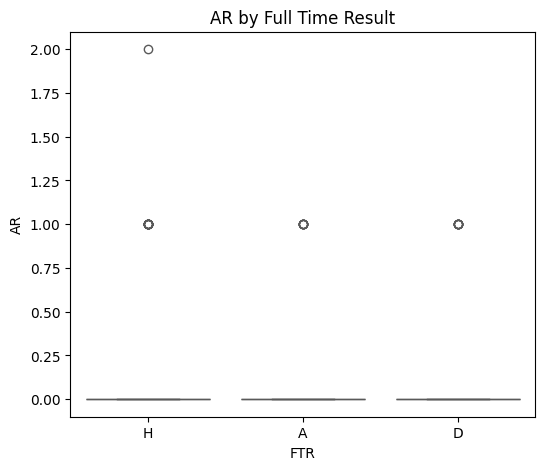

In [9]:
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs Full Time Result (FTR)
# -------------------------------------------------------------
target_col = "FTR"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} by Full Time Result")
        plt.show()

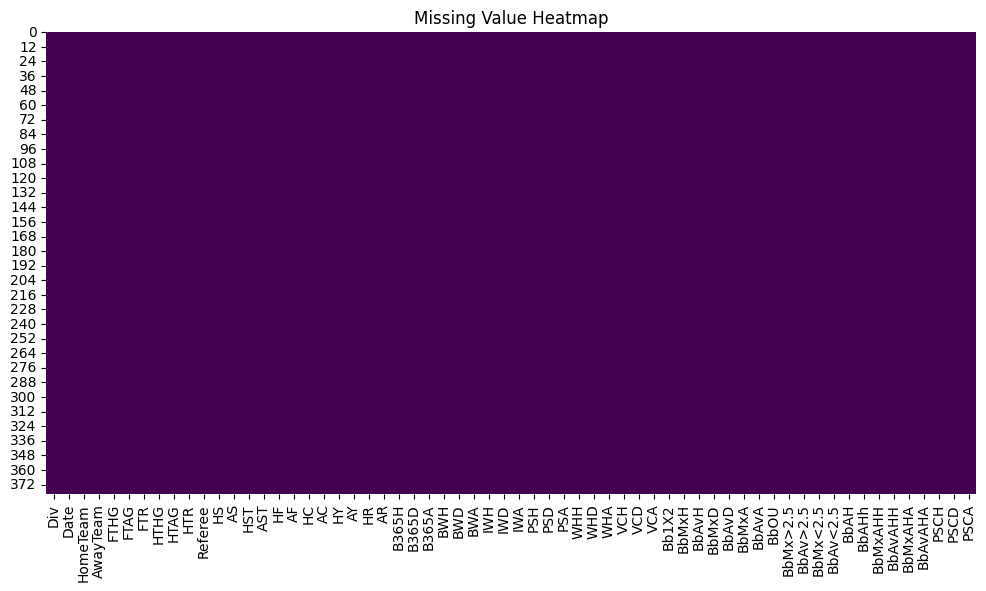

In [10]:
import matplotlib.pyplot as plt
fig1 = plt.figure(figsize=(12,6))

sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

### **Observation**

The missing value heatmap shows a uniform color across all features, indicating that the dataset does not contain missing values. Therefore, no data imputation is required before analysis.

<Figure size 1500x800 with 0 Axes>

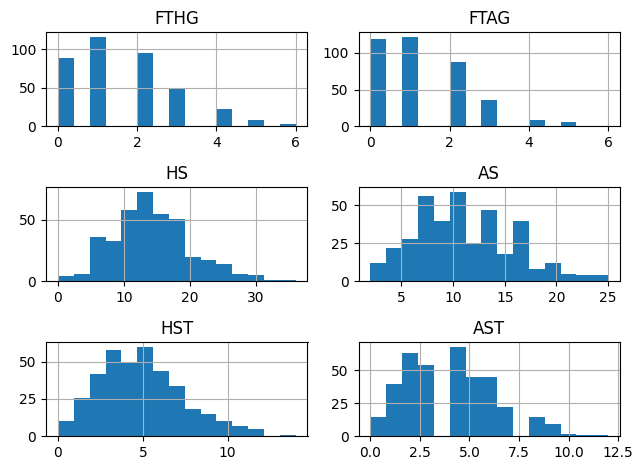

In [11]:
features = ["FTHG", "FTAG", "HS", "AS", "HST", "AST"]

fig2 = plt.figure(figsize=(15,8))
df[features].hist(
    bins=15
)

plt.tight_layout()

plt.show()

#Observations:
### **1. Full Time Goals (FTHG / FTAG)**

Observation:

- Most matches have between 0 and 3 goals scored by either the home or away team.
- Home teams (FTHG) tend to score slightly more goals on average than away teams (FTAG), reflecting home advantage.
- High-scoring matches (4+ goals by one team) are rare, so the distributions are right-skewed.

### **2. Shots (HS / AS) and Shots on Target (HST / AST)**

Observation:

- Total shots per match are roughly bell-shaped, typically ranging from 5 to 20 per team.
- Shots on target are naturally lower than total shots and show a similar, slightly right-skewed spread.

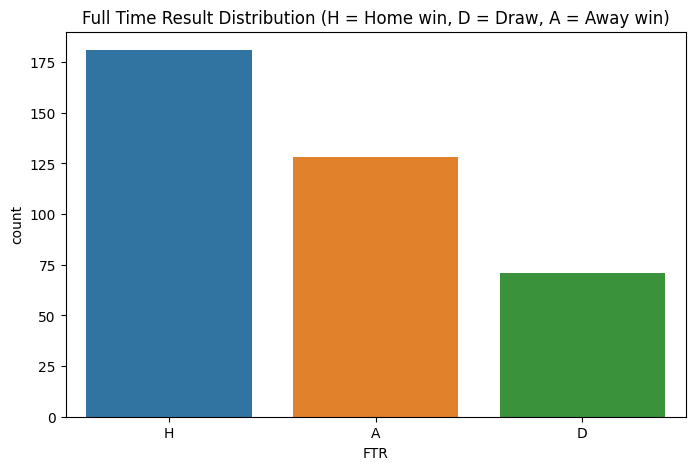

In [12]:
# Distribution of match results (Home win / Draw / Away win)

fig3 = plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="FTR",
    hue="FTR"
)

plt.title("Full Time Result Distribution (H = Home win, D = Draw, A = Away win)")

plt.show()

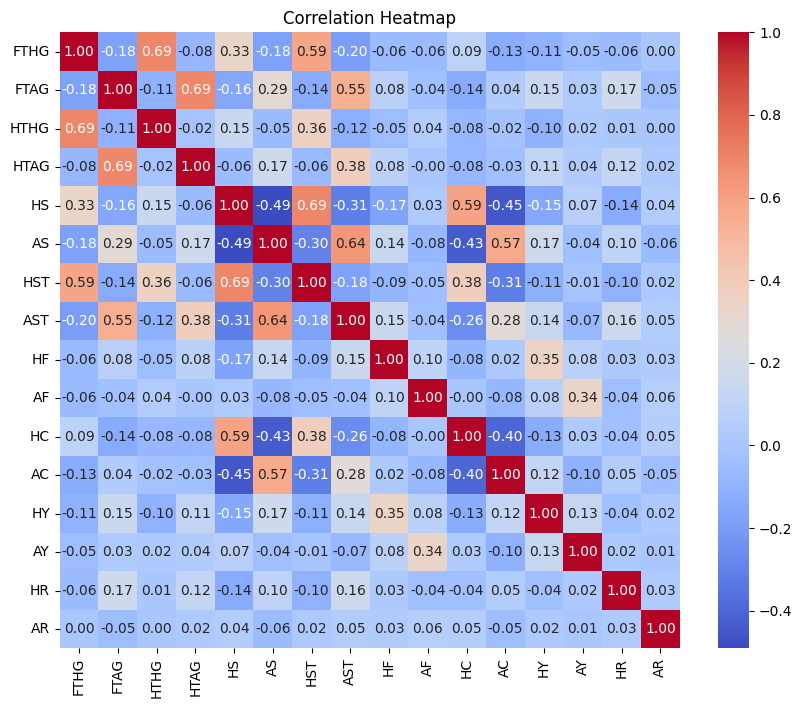

In [13]:
#Correlation Heatmap

fig5 = plt.figure(figsize=(10,8))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Correlation Heatmap

To identify the relationship among numerical features and understand which variables are positively or negatively correlated before model development.
A correlation heatmap visualizes the Pearson correlation coefficient between numerical features.

The correlation coefficient (r) ranges from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

Generally,

- **0.70 to 1.00** → Strong positive correlation
- **0.40 to 0.69** → Moderate positive correlation
- **0.00 to 0.39** → Weak positive correlation
- **-0.40 to -0.69** → Moderate negative correlation
- **-0.70 to -1.00** → Strong negative correlation

##Example:

# **1. Coding Skills vs Certifications = 0.86**
Observation
-A strong positive relationship exists.
-Students with better coding skills usually earn more certifications.
-Certifications appear to reflect technical competency.


# 2. Student_ID, Correlation ≈ 0
Observation

- It has no relationship with placement or academic performance.
- It should be removed before model training.

#3.CGPA vs Backlogs = -0.58
    -As CGPA increases, the number of backlogs generally decreases.

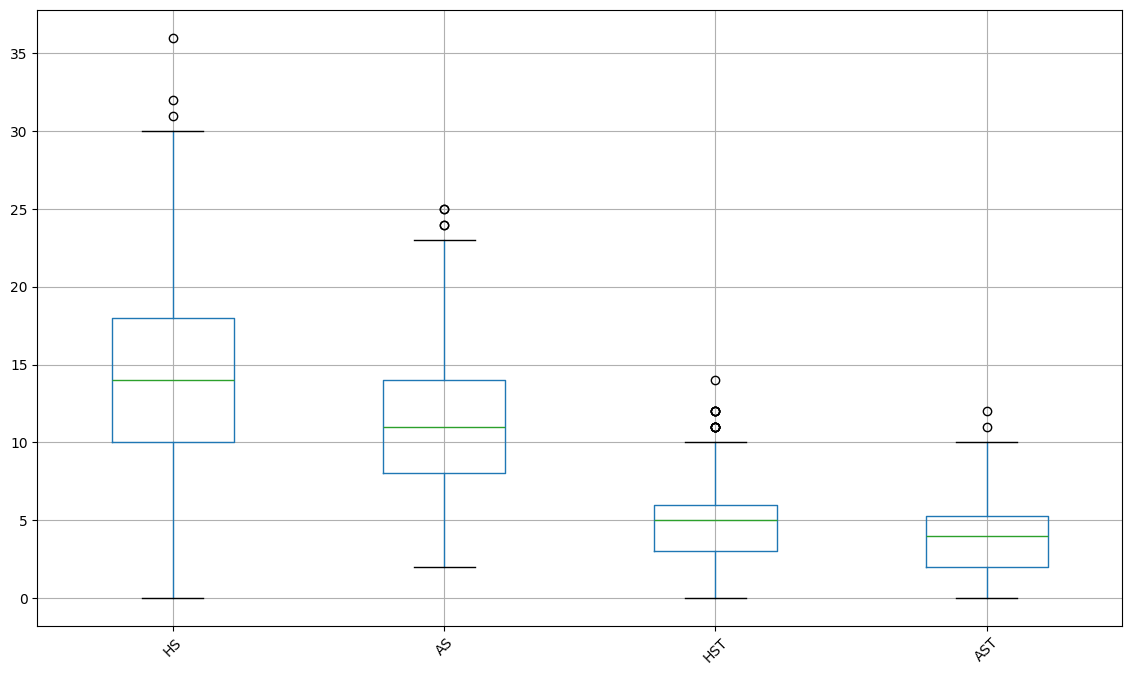

In [14]:
#boxplots
numerical_columns = [
    "HS",
    "AS",
    "HST",
    "AST"
]


fig6 = plt.figure(figsize=(14,8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

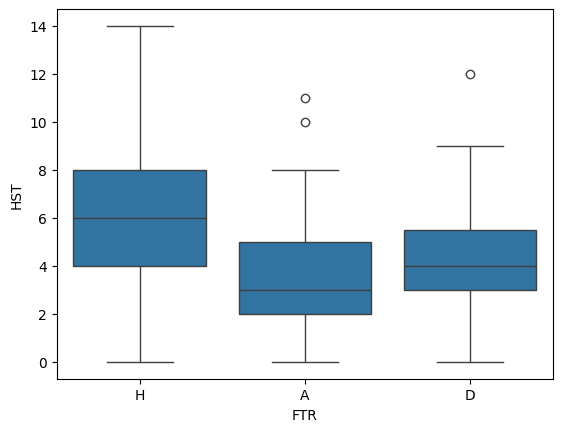

In [15]:
fig7 = sns.boxplot(x='FTR', y='HST', data=df)

In [16]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)


print("EDA Report saved successfully.")

EDA Report saved successfully.
